<hr>
<h1 style="text-align: center;">Introduction to Aerodynamics and Python</h1>
<hr>

<h3 style="text-align: center;">Ephraim Aung</h3>
<h3 style="text-align: center;">Student ID: 920074048</h3>
<h3 style="text-align: center;">Project #: 0</h3>
<h3 style="text-align: center;">Date:10/11/2024 </h3>

<h3 style="text-align: center;">EAE 127: Applied Aerodynamics</h3>
<h3 style="text-align: center;">University of California, Davis</h3>

<hr>


<hr>

# **Local Software Environment Setup Acknowledgment**

I, [Ephraim Aung], acknowledge that I have downloaded and successfully setup Python, Anaconda, and my desired IDE on my working machine for this course prior to the submission of this assignment. 

[10/11/2024]


<hr>

**Setup**

In [27]:
#STANDARD IMPORTS
import numpy as np
import os
import matplotlib.pyplot as plt
### JUPYTER NOTEBOOK SETTINGS ########################################
#Plot all figures in full-size cells, no scroll bars
%matplotlib inline
#Disable Python Warning Output
#(NOTE: Only for production, comment out for debugging)
import warnings
warnings.filterwarnings('ignore')
### PLOTTING DEFAULTS BOILERPLATE (OPTIONAL) #########################
#SET DEFAULT FIGURE APPERANCE
import seaborn as sns #Fancy plotting package
#No Background fill, legend font scale, frame on legend
sns.set(style='whitegrid', font_scale=1.5, rc={'legend.frameon': True})
#Mark ticks with border on all four sides (overrides 'whitegrid')
sns.set_style('ticks')
#ticks point in
sns.set_style({"xtick.direction": "in","ytick.direction": "in"})
#fix invisible marker bug
sns.set_context(rc={'lines.markeredgewidth': 0.1})
#restore default matplotlib colormap
mplcolors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
'#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
sns.set_palette(mplcolors)

#Get color cycle for manual colors
colors = sns.color_palette()
#SET MATPLOTLIB DEFAULTS
#(call after seaborn, which changes some defaults)
params = {
#FONT SIZES
'axes.labelsize' : 30, #Axis Labels
'axes.titlesize' : 30, #Title
'font.size' : 28, #Textbox
'xtick.labelsize': 22, #Axis tick labels
'ytick.labelsize': 22, #Axis tick labels
'legend.fontsize': 24, #Legend font size
'font.family' : 'serif',
'font.fantasy' : 'xkcd',
'font.sans-serif': 'Helvetica',
'font.monospace' : 'Courier',
#AXIS PROPERTIES
'axes.titlepad' : 2*6.0, #title spacing from axis
'axes.grid' : True, #grid on plot
'figure.figsize' : (8,8), #square plots
'savefig.bbox' : 'tight', #reduce whitespace in saved figures
#LEGEND PROPERTIES
'legend.framealpha' : 0.5,
'legend.fancybox' : True,
'legend.frameon' : True,
'legend.numpoints' : 1,
'legend.scatterpoints' : 1,
'legend.borderpad' : 0.1,
'legend.borderaxespad' : 0.1,
'legend.handletextpad' : 0.2,
'legend.handlelength' : 1.0,
'legend.labelspacing' : 0,
}
import matplotlib
matplotlib.rcParams.update(params) #update matplotlib defaults, call after￿
### END OF BOILERPLATE ##################################################
colors = sns.color_palette() #color cycle

**1.0 Boundary Layers and Numerical Integration**

**1.1 Turbulent and Laminar Boundary Layer Velocity Profile**

In [28]:
#Reference Parameters
L = 300     #fuselage length [ft]
Re = 1e8    #Reynolds Number (turbulent flow)

In [29]:
#Boundary Layer Profile (Create data for plot)
ynon= np.linspace(0,1,201)
unon_L= 2*(ynon)-(ynon)**2 #Laminar
unon_T= ynon ** (1/7) #Turbulent

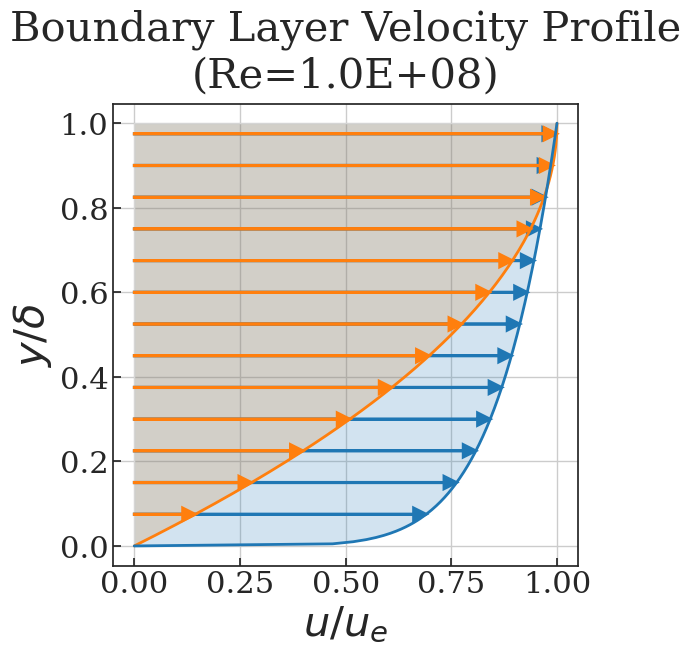

In [30]:
#Plot both of the BL Velocity Profiles
plt.figure(figsize=(6,6))
plt.title('Boundary Layer Velocity Profile\n(Re={:1.1E})'.format(Re))
plt.xlabel("$u/u_e$")
plt.ylabel("$y / \\delta$")
line = 2 

plt.plot(unon_L, ynon, color=colors[1], linewidth=line) #Laminar Curve
plt.plot(unon_T, ynon, color=colors[0], linewidth=line) #Turbulent Curve
vertlinex = np.zeros(len(ynon)) #Y-axis reference
plt.fill_betweenx(ynon, vertlinex, unon_L, facecolor=colors[1], alpha=0.2) #Color area left of Laminar Curve
plt.fill_betweenx(ynon, vertlinex, unon_T, facecolor=colors[0], alpha=0.2) #Color area left of Turbulent Curve
wd, ln = 0.03, 0.03 #Create dimensions for arrow heads

#plot horizontal lines and apply arrow heads to Turbulent Curve
for i in range(0, len(ynon), 15):
    if abs(unon_T[i]) < ln:
        plt.plot([0, unon_T[i]], [ynon[i], ynon[i]], color=colors[0],linewidth=line)
    else:
        plt.arrow(0, ynon[i], unon_T[i]-ln, 0, head_width=wd, head_length=ln, fc=colors[0], ec=colors[0], linewidth=line)
#plot horizontal lines and apply arrow heads to Laminar Curve
for i in range(0, len(ynon), 15):
    if abs(unon_L[i]) < ln:
        plt.plot([0, unon_L[i]], [ynon[i], ynon[i]], color=colors[1],linewidth=line)
    else:
        plt.arrow(0, ynon[i], unon_L[i]-ln, 0, head_width=wd, head_length=ln, fc=colors[1], ec=colors[1], linewidth=line)

plt.axis([min(unon_T), max(unon_T), min(ynon), max(ynon)]) #set bounds
plt.axis('equal') #scale both equally

#show plot on Jupiter Notebook
plt.show()

#Save Figure. File extension (i.e. '.png', '.pdf') will set filetype
#plt.savefig('{}/pj0_1_BLVelProfile.png'.format(savedir), bbox_inches='tight')

**Figure 1** - Horizontal velocity profile at x = 300 f t aft of the nose on a 747 fuselage. Velocity
variation along a vertical line is shown to increase exponentially from zero at the fuselage wall.

**1.2 Boundary Layer Thickness**

In [31]:
#non-dim. displacement thickness
delta_star_non = np.trapz(1 - unon_L, ynon) #integrate vel. profile according to eqn above
#dimensional boundary layer thicknes at aft [ft]
delta = L * 0.16 / (Re ** (1 / 7)) #Blausius turbulent flat plate BL thickness eqn
#re-dimensionalize disp. thickness
delta_star = delta_star_non * delta
print('|------------------------------------------------------------------|')
print('|Displacement Thickness: {} in (Re={:1.1E}, L={})|'.format(delta_star*12, Re, L) )
print('|------------------------------------------------------------------|')
print('Laminar BL Thickness: {} in'.format(delta*12) )

|------------------------------------------------------------------|
|Displacement Thickness: 13.818137646183644 in (Re=1.0E+08, L=300)|
|------------------------------------------------------------------|
Laminar BL Thickness: 41.45389476486636 in


In [32]:
#non-dim. displacement thickness
delta_star_non = np.trapz(1 - unon_T, ynon) #integrate vel. profile according to eqn above
#dimensional boundary layer thicknes at aft [ft]
delta = L * 0.16 / (Re ** (1 / 7)) #Blausius turbulent flat plate BL thickness eqn
#re-dimensionalize disp. thickness
delta_star = delta_star_non * delta
print('|------------------------------------------------------------------|')
print('|Displacement Thickness: {} in (Re={:1.1E}, L={})|'.format(delta_star*12, Re, L) )
print('|------------------------------------------------------------------|')
print(' Turbulent BL Thickness: {} in'.format(delta*12) )

|------------------------------------------------------------------|
|Displacement Thickness: 5.219319208243424 in (Re=1.0E+08, L=300)|
|------------------------------------------------------------------|
 Turbulent BL Thickness: 41.45389476486636 in


**2.0 Airfoil Plotting and Line Integrals**

**2.1 Airfoil Plotting**

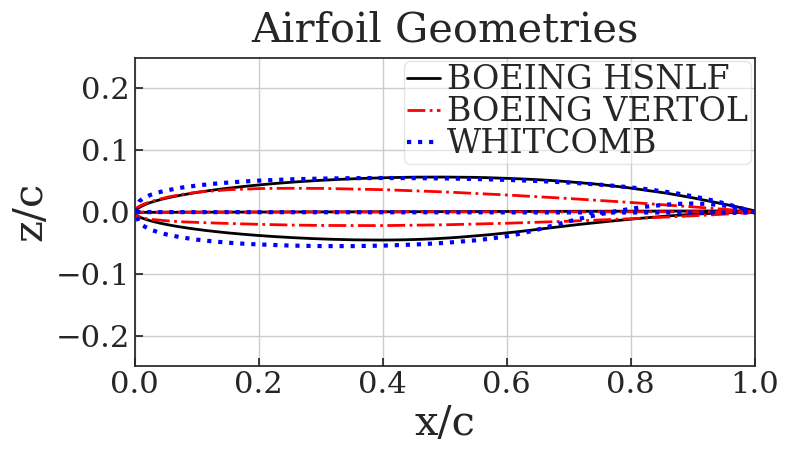

In [33]:
filename = "../bacnlf.txt"
xb12, zb12 = np.loadtxt(filename, skiprows = 1, unpack = True)

filename = "../v13006.txt"
xv12, zv12 = np.loadtxt(filename, skiprows = 1, unpack = True)

filename = "../whitcomb.txt"
xw611, zw611 = np.loadtxt(filename, skiprows = 1, unpack = True)

#Start Figure
plt.figure(figsize=(8,4))
plt.title('Airfoil Geometries') 
plt.xlabel("x/c") 
plt.ylabel("z/c") 
#Plot Airfoil Data
plt.plot(xb12, zb12, label="BOEING HSNLF", color='black', linestyle="-", linewidth=2, markersize=8)
plt.plot(xv12, zv12, label="BOEING VERTOL", color='red', linestyle="-.", linewidth=2, markersize=4)
plt.plot(xw611, zw611, label="WHITCOMB", color='blue', linestyle=":", linewidth=3, markersize=2)
plt.grid(True) 
#Force Axis to have equal scale (VERY important for geometry plots)
plt.axis('equal') #************************************************************
plt.xlim([0, 1]) #Lock x-axis to airfoil
#Plot Legend 
plt.legend(loc='best')

**3.0 Airfoil Surface Pressure and Numeric Differentiation**

**3.1 Airfoil Surface Pressure**

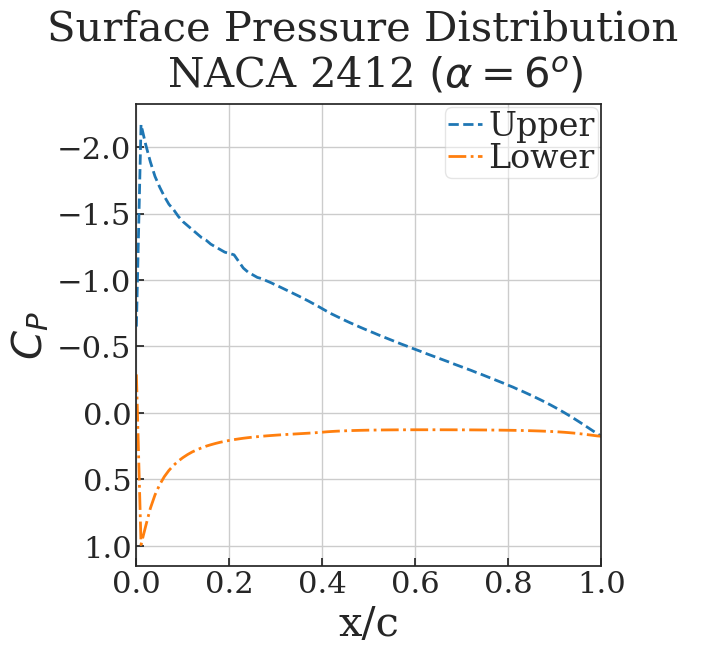

In [34]:
#Import Data
filename = '../naca2412_SurfPress_a6.csv'
x, Cpl, Cpu = np.loadtxt(filename, skiprows=1, unpack=True, delimiter=',')
plt.figure(figsize=(6,6))
plt.title('Surface Pressure Distribution \n NACA 2412 $(\\alpha=6^o)$')
plt.xlabel("x/c") 
plt.ylabel("$C_P$") 

plt.gca().invert_yaxis() #Invert Y-Axis

#Plot Airfoil Data
plt.plot(x, Cpu, label='Upper', linewidth=2, linestyle='--')
plt.plot(x, Cpl, label='Lower', linewidth=2, linestyle='-.')
plt.grid(True) 
plt.xlim([0, 1])
plt.legend(loc='best')

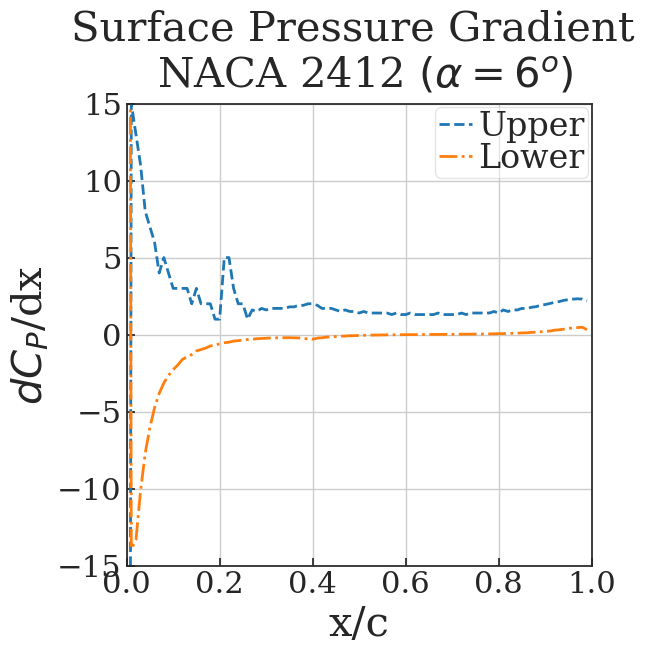

In [35]:
dCpudx = np.zeros(len(Cpu) - 1)
dCpldx = np.zeros(len(Cpl) - 1)
for i in range(len(dCpudx)):
    dCpudx[i] = (Cpu[i+1] - Cpu[i]) / (x[i+1] - x[i]) 
    dCpldx[i] = (Cpl[i+1] - Cpl[i]) / (x[i+1] - x[i])
    
#Plot Pressure Gradient
plt.figure(figsize=(6,6))
plt.title('Surface Pressure Gradient \n NACA 2412 $(\\alpha=6^o)$')
plt.xlabel("x/c") 
plt.ylabel("$dC_P$/dx") 

#Plot Airfoil Data
plt.plot(x[:-1], dCpudx, label='Upper', linewidth=2, linestyle='--')
plt.plot(x[:-1], dCpldx, label='Lower', linewidth=2, linestyle='-.')
plt.grid(True) 
plt.xlim([0, 1])
plt.ylim([-15, 15]) 
plt.legend(loc='best') 

**4.0 Linear Algebra**

In [36]:
#Variable Matrix A
A = np.array([
[1, 2, 3, 4],
[3, 2, -2, 3],
[0, 1, 1, 0],
[2, 1, 1, -2]
])
#Resultant Matrix b
b = np.array([12, 10, -1, -5])
#Solve
soln = np.linalg.solve(A, b)
#Display nicely :)
print('\nSolving:')
print('A =', A)
print('b =', b)
print('Results in:')
for var, val in zip('wxyz', soln): #loop through letters in string and list
    print('{} = {:1.6f}'.format(var, val))



Solving:
A = [[ 1  2  3  4]
 [ 3  2 -2  3]
 [ 0  1  1  0]
 [ 2  1  1 -2]]
b = [12 10 -1 -5]
Results in:
w = 1.153846
x = -1.230769
y = 0.230769
z = 3.153846


**5.0 Lift Curves and Linear Interpolation**

**5.1 Lift Curves**

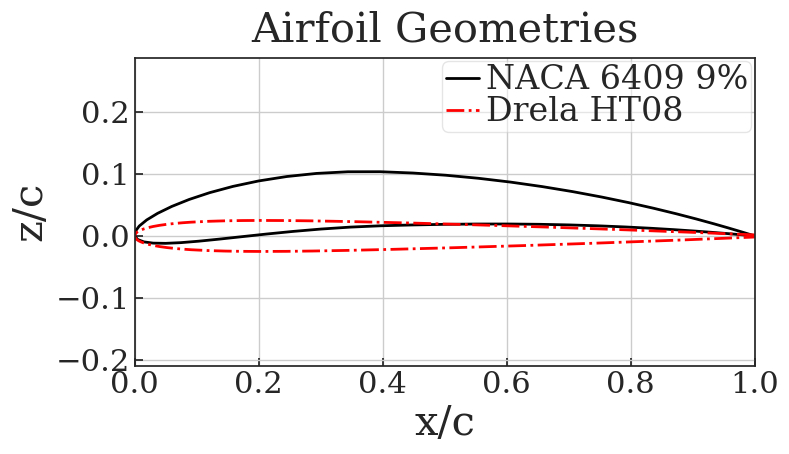

In [37]:
#Geometries

filename = "../n6409.txt"
xb12, zb12 = np.loadtxt(filename, skiprows = 1, unpack = True)

filename = "../ht08.txt"
xv12, zv12 = np.loadtxt(filename, skiprows = 1, unpack = True)

#Start Figure
plt.figure(figsize=(8,4))
plt.title('Airfoil Geometries') 
plt.xlabel("x/c") 
plt.ylabel("z/c") 
#Plot Airfoil Data
plt.plot(xb12, zb12, label="NACA 6409 9%", color='black', linestyle="-", linewidth=2, markersize=8)
plt.plot(xv12, zv12, label="Drela HT08", color='red', linestyle="-.", linewidth=2, markersize=4)
plt.grid(True) 
#Force Axis to have equal scale (VERY important for geometry plots)
plt.axis('equal') #************************************************************
plt.xlim([0, 1]) #Lock x-axis to airfoil
#Plot Legend located in 'best' space
plt.legend(loc='best')

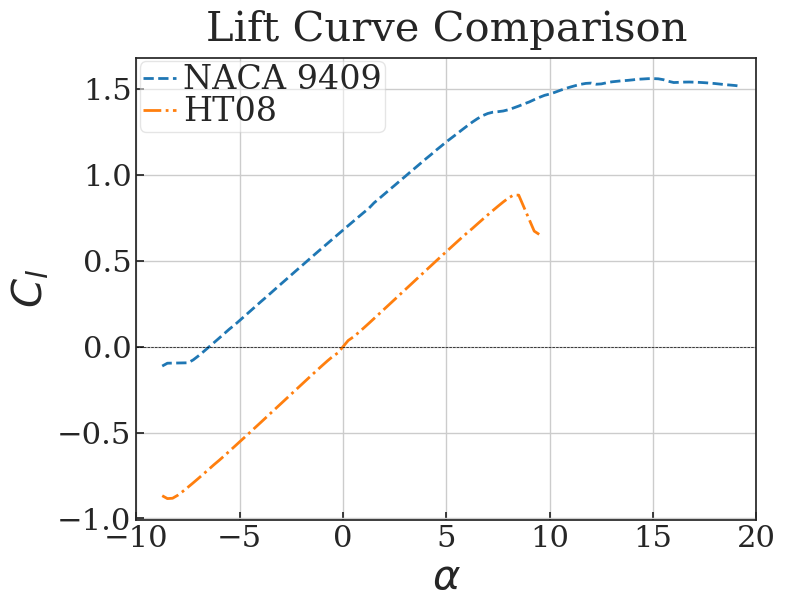

In [38]:
#Lift Curves
#For Re = 1,000,000
#Import Data
filename = '../xf-n6409-il-1000000.csv'
AlphaN, ClN = np.loadtxt(filename, skiprows=11, unpack=True, delimiter=',',usecols=(0,1))
filename = '../xf-ht08-il-1000000.csv'
AlphaH, ClH = np.loadtxt(filename, skiprows=11, unpack=True, delimiter=',',usecols=(0,1))
plt.figure(figsize=(8,6))
plt.title('Lift Curve Comparison')
plt.xlabel("$\\alpha$") 
plt.ylabel("$C_l$") 


#Plot Airfoil Data
plt.plot(AlphaN, ClN, label='NACA 9409', linewidth=2, linestyle='--')
plt.plot(AlphaH, ClH, label='HT08', linewidth=2, linestyle='-.')
plt.grid(True) 
plt.xlim([-10, 20])
plt.legend(loc='best')

plt.axhline(0, color='black', linewidth=0.5, linestyle='--')

The NACA 9409 Airfoil has a higher range of operation in terms of angle of attack. Additionally, the Coefficient of lift of the NACA 9409 is higher at every angle. Something else to notice is that the y-intercept of both airfoils confirms whether the shape is symmetrical vs cambered.

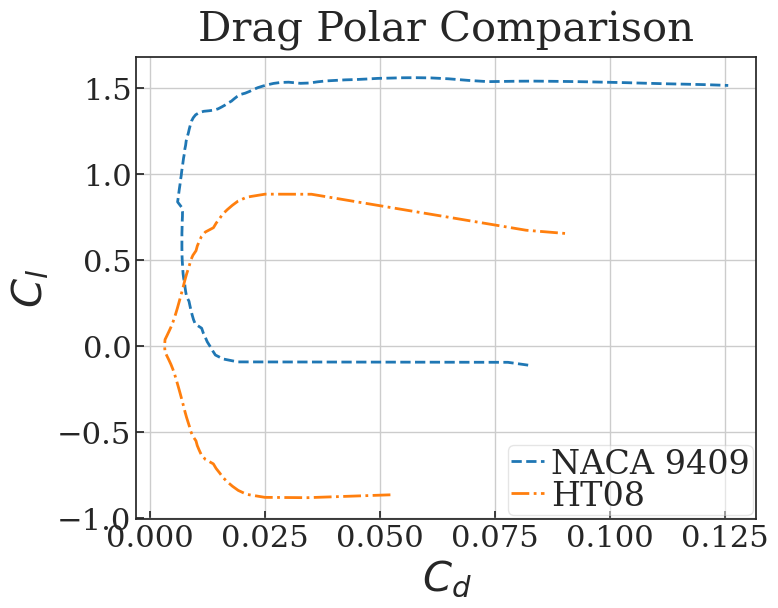

In [39]:
#Drag Polars
#For Re = 1,000,000
#Import Data
filename = '../xf-n6409-il-1000000.csv'
ClN, CdN = np.loadtxt(filename, skiprows=11, unpack=True, delimiter=',',usecols=(1,2))
filename = '../xf-ht08-il-1000000.csv'
ClH, CdH = np.loadtxt(filename, skiprows=11, unpack=True, delimiter=',',usecols=(1,2))
plt.figure(figsize=(8,6))
plt.title('Drag Polar Comparison')
plt.xlabel("$C_d$") 
plt.ylabel("$C_l$") 

#Plot Airfoil Data
plt.plot(CdN, ClN, label='NACA 9409', linewidth=2, linestyle='--')
plt.plot(CdH, ClH, label='HT08', linewidth=2, linestyle='-.')
plt.grid(True) 
plt.legend(loc='best')


The Drag Polar plots of each airfoil show the relationship between Lift and Drag for each airfoil. The symmetrical HT08 Airfoil has a less extreme relationship between Cd and Cl whereas the cambered NACA 9409 has a higher rate of change.

**5.2 Linear Interpolation**

In [40]:
# Load the polar data for the HT08-IL airfoil
filename_ht08 = '../xf-ht08-il-1000000.csv'
AlphaH, ClH = np.loadtxt(filename_ht08, skiprows=11, unpack=True, delimiter=',', usecols=(0, 1))

# Load the polar data for the N6409 airfoil
filename_n6409 = '../xf-n6409-il-1000000.csv'
AlphaN, ClN = np.loadtxt(filename_n6409, skiprows=11, unpack=True, delimiter=',', usecols=(0, 1))

# Angles of attack for interpolation
alpha_to_interpolate = [0.35, 10.1]

# Interpolate Cl for HT08-IL airfoil
Cl_ht08_alpha_035 = np.interp(0.35, AlphaH, ClH)
Cl_ht08_alpha_101 = np.interp(10.1, AlphaH, ClH)

# Interpolate Cl for N6409 airfoil
Cl_n6409_alpha_035 = np.interp(0.35, AlphaN, ClN)
Cl_n6409_alpha_101 = np.interp(10.1, AlphaN, ClN)

# Print the results
print(f"HT08-IL Airfoil:")
print(f"Cl at Alpha = 0.35°: {Cl_ht08_alpha_035:.4f}")
print(f"Cl at Alpha = 10.1°: {Cl_ht08_alpha_101:.4f}")

print(f"\nN6409 Airfoil:")
print(f"Cl at Alpha = 0.35°: {Cl_n6409_alpha_035:.4f}")
print(f"Cl at Alpha = 10.1°: {Cl_n6409_alpha_101:.4f}")




HT08-IL Airfoil:
Cl at Alpha = 0.35°: 0.0445
Cl at Alpha = 10.1°: 0.6530

N6409 Airfoil:
Cl at Alpha = 0.35°: 0.7149
Cl at Alpha = 10.1°: 1.4749


**Maximum Lift Calculation**

In [41]:

#NACA 6409

filename = '../xf-n6409-il-1000000.csv'
AlphaN, ClN = np.loadtxt(filename, skiprows=11, unpack=True, delimiter=',', usecols=(0, 1))


max_Cl_index = np.argmax(ClN) 
max_Cl = ClN[max_Cl_index]  # Maximum Cl value
alpha_at_max_Cl = AlphaN[max_Cl_index]  # Corresponding Alpha value

# Print the maximum Cl and corresponding Alpha values
print(f"Maximum C_l: {max_Cl:.4f} at α = {alpha_at_max_Cl:.2f}°")

#Define Variables
V=180 #meters/second
Si=200
Sm=Si*0.092903 #meters
Rho=1.225 #kg/m^3 sea level
Cl=max_Cl

L= 0.5*Rho*(V**2)*Sm*Cl
print(f"Maximum Lift: {L:.4f} Newtons")

Maximum C_l: 1.5608 at α = 15.00°
Maximum Lift: 575516.9165 Newtons


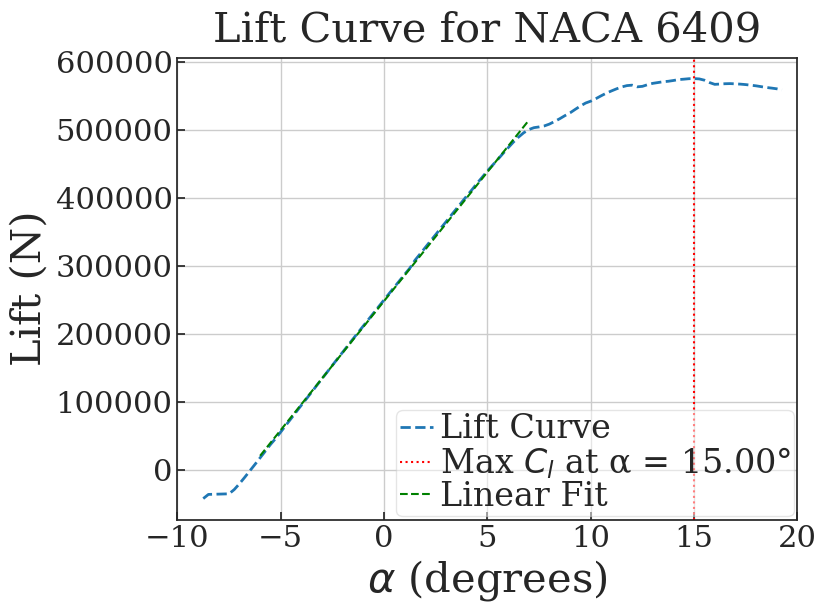

Maximum C_l: 1.5608 at α = 15.00°
Maximum Lift: 575516.9165 Newtons
Lift Curve Slope (dL/dα): 37911.0139 N/degree


In [42]:

filename = '../xf-n6409-il-1000000.csv'
AlphaN, ClN = np.loadtxt(filename, skiprows=11, unpack=True, delimiter=',', usecols=(0, 1))

# Define Variables
V = 180  # Velocity in meters/second
Si = 200  # Wing area in ft²
Sm = Si * 0.092903  # Convert area to m²
Rho = 1.225  # Air density in kg/m³ (sea level)

# Calculate Lift 
L = 0.5 * Rho * (V**2) * Sm * ClN  

# Find maximum Cl value
max_Cl_index = np.argmax(ClN)
max_Cl = ClN[max_Cl_index]  
alpha_at_max_Cl = AlphaN[max_Cl_index]  # Corresponding Alpha value


linear_region_indices = np.where((AlphaN >= -6) & (AlphaN <= 7))  # Adjust
alpha_linear = AlphaN[linear_region_indices]
Cl_linear = ClN[linear_region_indices]
L_linear = L[linear_region_indices]  

# linear regression
slope, intercept = np.polyfit(alpha_linear, L_linear, 1) 


plt.figure(figsize=(8, 6))
plt.title('Lift Curve for NACA 6409')
plt.xlabel("$\\alpha$ (degrees)")
plt.ylabel("Lift (N)")


plt.plot(AlphaN, L, label='Lift Curve', linewidth=2, linestyle='--')
plt.axvline(alpha_at_max_Cl, color='red', linestyle=':', label=f'Max $C_l$ at α = {alpha_at_max_Cl:.2f}°')


plt.plot(alpha_linear, slope * alpha_linear + intercept, color='green', linestyle='--', label='Linear Fit')

plt.grid(True)
plt.xlim([-10, 20])
plt.legend(loc='best')
plt.show()

# Print the maximum Cl and corresponding Alpha values
print(f"Maximum C_l: {max_Cl:.4f} at α = {alpha_at_max_Cl:.2f}°")


# Calculate Maximum Lift using the maximum Cl
L_max = 0.5 * Rho * (V**2) * Sm * max_Cl
print(f"Maximum Lift: {L_max:.4f} Newtons")
print(f"Lift Curve Slope (dL/dα): {slope:.4f} N/degree") 
